# Task1

In [17]:
import numpy as np
def generate_gaussian_distribution_points(mean,rho,sigma1,sigma2,num=100):
    conv=[
        [sigma1**2,rho*sigma1*sigma2],
        [rho*sigma1*sigma2,sigma2**2]
    ]
    X=np.random.multivariate_normal(mean,conv,num)
    return X


In [18]:
X1=generate_gaussian_distribution_points([1,2],0.2,2,2)
X2=generate_gaussian_distribution_points([2,-1],0.8,4,2)

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gaussian_points(X1, X2, title="Gaussian Distributions"):
    plt.figure(figsize=(6, 6))
    plt.scatter(X1[:, 0], X1[:, 1], c='blue', label='Class 1', alpha=0.6)
    plt.scatter(X2[:, 0], X2[:, 1], c='red', label='Class 2', alpha=0.6)
    plt.title(title)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.grid(True)
    plt.show()


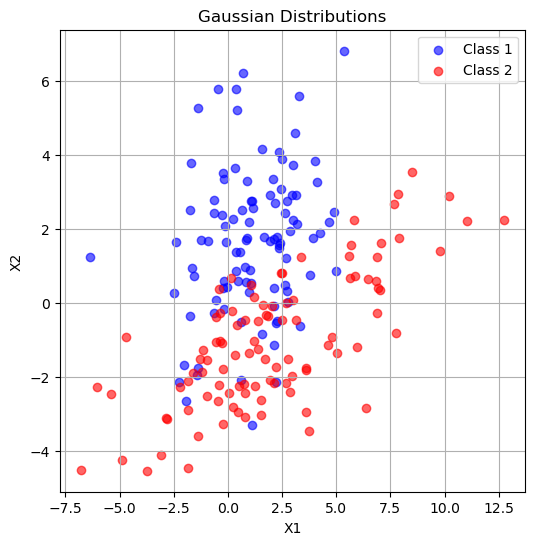

In [20]:
plot_gaussian_points(X1,X2)

In [21]:
def split_train_test(X1, X2, train_ratio=0.8):
    n = len(X1)
    n_train = int(n * train_ratio)

    idx1 = np.random.permutation(n)
    idx2 = np.random.permutation(n)

    X1_train, X1_test = X1[idx1[:n_train]], X1[idx1[n_train:]]
    X2_train, X2_test = X2[idx2[:n_train]], X2[idx2[n_train:]]

    X_train = np.vstack((X1_train, X2_train))
    y_train = np.hstack((np.ones(n_train), -np.ones(n_train)))
    X_test = np.vstack((X1_test, X2_test))
    y_test = np.hstack((np.ones(n - n_train), -np.ones(n - n_train)))

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = split_train_test(X1, X2, train_ratio=0.8)

print("train_set:", X_train.shape, y_train.shape)
print("test_set", X_test.shape, y_test.shape)

train_set: (160, 2) (160,)
test_set (40, 2) (40,)


# Task2
in perceptron.py

# Task3

In [ ]:
from perceptron import Perceptron
p = Perceptron(n_inputs=2, max_epochs=1000, learning_rate=0.1)
p.train(X_train, y_train)

y_pred_test = p.forward(X_test)
acc = (y_pred_test == y_test).mean()
print("test accuracy:", acc)

test accuracy: 0.8


# Task4

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def run_experiment(mean1, mean2, rho1, rho2, sigma1_1, sigma1_2, sigma2_1, sigma2_2,
                   num_points=100, train_ratio=0.8,
                   max_epochs=200, learning_rate=0.01, plot=False):

    X1 = generate_gaussian_distribution_points(mean1, rho1, sigma1_1, sigma1_2, num_points)
    X2 = generate_gaussian_distribution_points(mean2, rho2, sigma2_1, sigma2_2, num_points)

    X_train, y_train, X_test, y_test = split_train_test(X1, X2, train_ratio)

    model = Perceptron(n_inputs=2, max_epochs=max_epochs, learning_rate=learning_rate)
    model.train(X_train, y_train)

    y_pred_test = model.forward(X_test)
    acc_test = np.mean(y_pred_test == y_test)

    print("="*60)
    print(f"Mean1={mean1}, Mean2={mean2}")
    print(f"Sigma1=({sigma1_1},{sigma1_2}), Sigma2=({sigma2_1},{sigma2_2})")
    print(f"ρ1={rho1}, ρ2={rho2}")
    print(f"Test Accuracy = {acc_test:.3f}")
    print("="*60)

    if plot:
        plt.figure(figsize=(6,6))
        plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], c='blue', label='Class 1 (train)', alpha=0.5)
        plt.scatter(X_train[y_train==-1,0], X_train[y_train==-1,1], c='red', label='Class -1 (train)', alpha=0.5)
        plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1], c='blue', marker='x', label='Class 1 (test)')
        plt.scatter(X_test[y_test==-1,0], X_test[y_test==-1,1], c='red', marker='x', label='Class -1 (test)')
        plt.legend()
        plt.title(f"Means={mean1},{mean2} | Var={sigma1_1,sigma1_2},{sigma2_1,sigma2_2}\nAcc={acc_test:.3f}")
        plt.grid(True)
        plt.show()

    return acc_test

Mean1=[0, 0], Mean2=[4, 4]
Sigma1=(2,1), Sigma2=(0.6,2)
ρ1=0.2, ρ2=0.3
Test Accuracy = 0.950


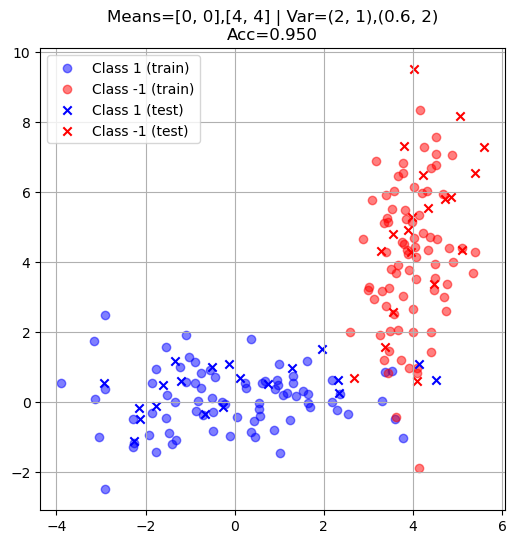

Mean1=[1.1, 1.3], Mean2=[1.2, 1.2]
Sigma1=(0.4,0.2), Sigma2=(0.15,0.5)
ρ1=0.2, ρ2=0.3
Test Accuracy = 0.575


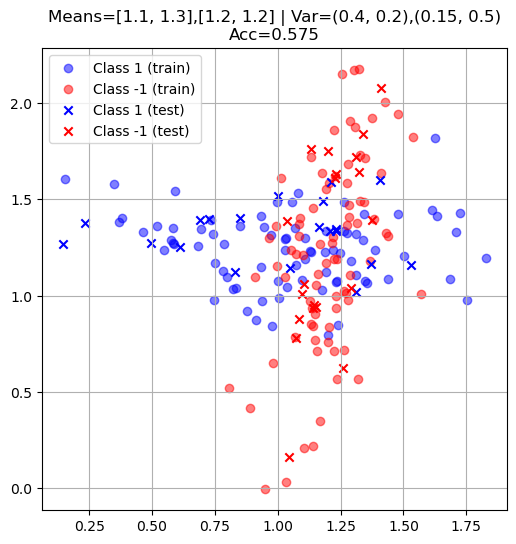

Mean1=[0.4, 0.4], Mean2=[0.5, 0.5]
Sigma1=(5,4), Sigma2=(5,6)
ρ1=0.2, ρ2=0.1
Test Accuracy = 0.500


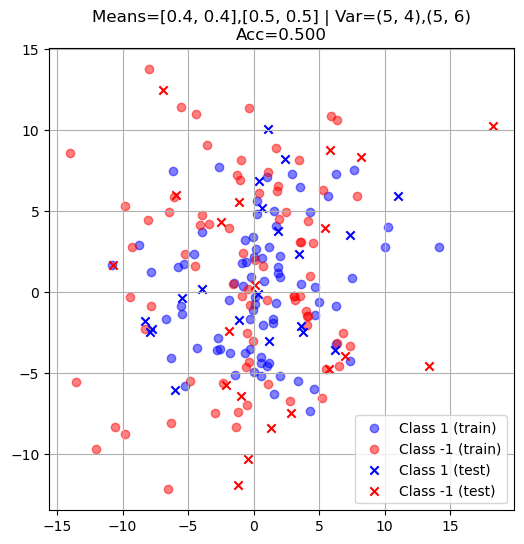

Mean1=[0, 0], Mean2=[5, 5]
Sigma1=(3.5,3), Sigma2=(3,4)
ρ1=0.0, ρ2=0.26
Test Accuracy = 0.850


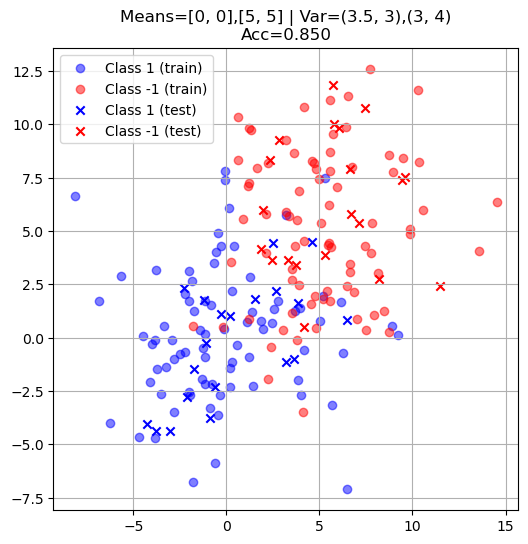


📊 Summary of all experiments:
Experiment 1: Test Accuracy = 0.950
Experiment 2: Test Accuracy = 0.575
Experiment 3: Test Accuracy = 0.500
Experiment 4: Test Accuracy = 0.850


In [ ]:
experiments = [
    # case1: 均值远，方差小
    {"mean1": [0, 0], "mean2": [4, 4], "rho1": 0.2, "rho2": 0.3,
     "sigma1_1": 2, "sigma1_2": 1, "sigma2_1": 0.6, "sigma2_2": 2},
    
    # case2: 均值近，方差小
    {"mean1": [1.1, 1.3], "mean2": [1.2, 1.2], "rho1": 0.2, "rho2": 0.3,
     "sigma1_1": 0.4, "sigma1_2": 0.2, "sigma2_1": 0.15, "sigma2_2": 0.5},

    # case3: 均值近，方差大
    {"mean1": [0.4, 0.4], "mean2": [0.5, 0.5], "rho1": 0.2, "rho2": 0.1,
     "sigma1_1": 5, "sigma1_2": 4, "sigma2_1": 5, "sigma2_2": 6},

    # case4: 均值远，方差大
    {"mean1": [0, 0], "mean2": [5, 5], "rho1": 0.0, "rho2": 0.26,
     "sigma1_1": 3.5, "sigma1_2": 3, "sigma2_1": 3, "sigma2_2": 4}
]

results = []
for params in experiments:
    acc = run_experiment(**params, plot=True)
    results.append(acc)

print("\n📊 Summary of all experiments:")
for i, acc in enumerate(results):
    print(f"Experiment {i+1}: Test Accuracy = {acc:.3f}")